<a href="https://colab.research.google.com/github/StarGod-b/DataMining-SalesFootwear/blob/main/Association_Rule_Mining_ENG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Association Rule Mining Results**


In [ ]:
# =============================================================
# DATA COLLECTION: Import Library & Load Dataset
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import networkx as nx

import warnings
warnings.filterwarnings('ignore')

# ---- Global Style Configuration ----
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 10,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'figure.dpi'      : 300,
    'axes.grid'       : True,
    'grid.alpha'      : 0.35,
    'grid.linestyle'  : '--',
})

from google.colab import drive
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/Colab Notebooks/DWDM/global_sports_footwear_sales_2018_2026.csv'
df = pd.read_csv(PATH)

Mounted at /content/drive


---
### Data Preprocessing — One-Hot Encoding (OHE)
---

   ONE-HOT ENCODING (OHE) RESULTS
  Number of transactions (rows)  : 30,000
  Number of unique items (cols)   : 26
  Sparsity matrix           : 76.9%
  Item distribution per attribute:
    brand               : 6 item
    category            : 5 item
    gender              : 3 item
    payment_method      : 4 item
    country             : 6 item
    sales_channel       : 2 item


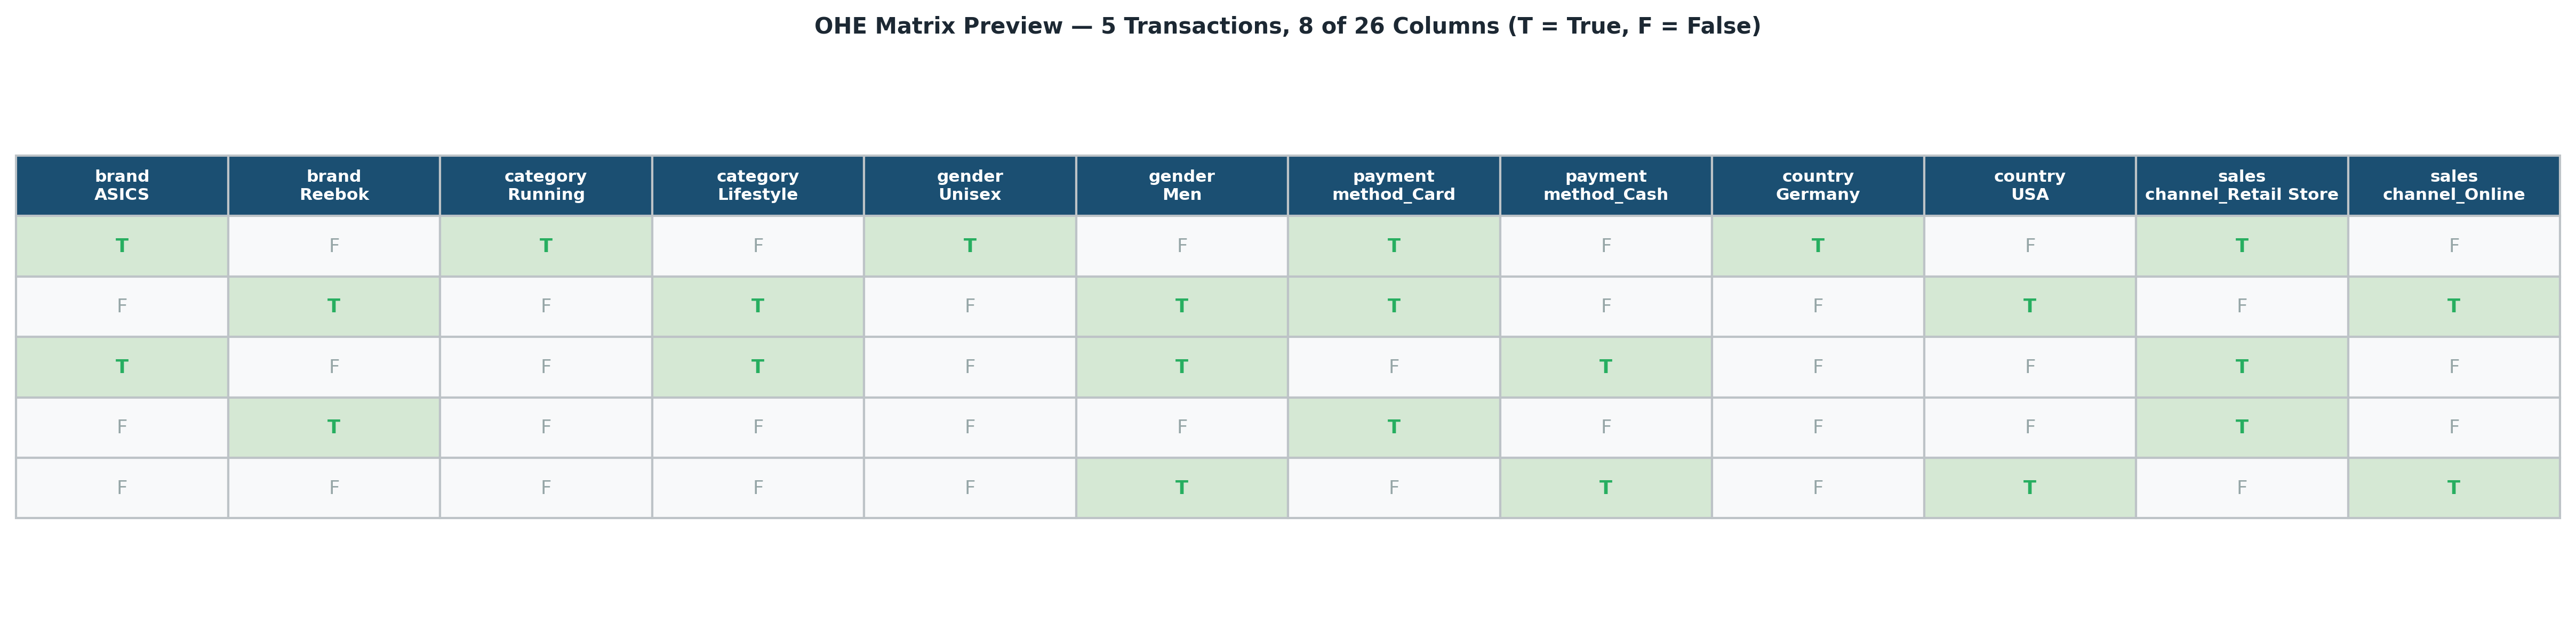

[✔] OHE matrix ready: shape = (30000, 26)


In [ ]:
# =============================================================
# PREPROCESSING ASSOCIATION — One-Hot Encoding (OHE)
# =============================================================
basket_cols = ['brand', 'category', 'gender',
               'payment_method', 'country', 'sales_channel']

ohe_data = {}
for col in basket_cols:
    for val in df[col].unique():
        ohe_data[f"{col}_{val}"] = (df[col] == val).astype(bool)

ohe_df = pd.DataFrame(ohe_data)

n_items  = ohe_df.shape[1]
n_tx     = ohe_df.shape[0]
sparsity = (1 - ohe_df.values.sum() / (n_tx * n_items)) * 100

print('=' * 58)
print('   ONE-HOT ENCODING (OHE) RESULTS')
print('=' * 58)
print(f'  Number of transactions (rows)  : {n_tx:,}')
print(f'  Number of unique items (cols)   : {n_items}')
print(f'  Sparsity matrix           : {sparsity:.1f}%')
print(f'  Item distribution per attribute:')
for col in basket_cols:
    cnt = len([c for c in ohe_df.columns if c.startswith(col + '_')])
    print(f'    {col:20s}: {cnt} item')

# ── Pilih 8 kolom representatif (2 per atribut pertama 4) ──
rep_cols = []
for col in ['brand', 'category', 'gender', 'payment_method',
            'country', 'sales_channel']:
    matched = [c for c in ohe_df.columns if c.startswith(col + '_')]
    rep_cols.extend(matched[:2])

ohe_preview = ohe_df[rep_cols].head(5).copy()
# Replace True/False with symbols for compactness
ohe_preview = ohe_preview.applymap(lambda x: 'T' if x else 'F')

# ── Styled matplotlib table ─────────────────────────────────
n_rows = len(ohe_preview) + 1   # +1 header
n_cols = len(ohe_preview.columns)
fig, ax = plt.subplots(figsize=(n_cols * 1.35, n_rows * 0.55 + 0.8))
ax.axis('off')

col_labels = [c.replace('_', '\n', 1) for c in ohe_preview.columns]
tbl = ax.table(
    cellText   = ohe_preview.values.tolist(),
    colLabels  = col_labels,
    cellLoc    = 'center',
    loc        = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 2.0)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#BDC3C7')
    if row == 0:
        cell.set_facecolor('#1B4F72')
        cell.set_text_props(color='white', weight='bold', size=7.5)
    elif cell.get_text().get_text() == 'T':
        cell.set_facecolor('#D5E8D4')    # hijau muda = True
        cell.set_text_props(color='#27AE60', weight='bold')
    else:
        cell.set_facecolor('#F8F9FA')    # abu sangat terang = False
        cell.set_text_props(color='#95A5A6')

ax.set_title(
    f'OHE Matrix Preview — 5 Transactions, 8 of {n_items} Columns '
    f'(T = True, F = False)',
    fontweight='bold', fontsize=10, pad=8, color='#1C2833'
)
plt.tight_layout()
plt.show()
print(f'[✔] OHE matrix ready: shape = {ohe_df.shape}')

---
### Modeling — Apriori Algorithm
---


  FREQUENT ITEMSETS EXTRACTION (APRIORI)
min_support    : 0.01 (1% of 30,000 transactions)
min_confidence : 0.1
min_lift       : 1.0

Processing... (please wait)

Processing 650 combinations | Sampling itemset size 2

[✔] Total frequent itemsets found     : 301
    - 1-itemsets : 26
    - 2-itemsets : 275

-- Top 15 Frequent Itemsets by Support --


,itemsets,support,length
0,(sales_channel_Retail Store),0.500300,1
1,(sales_channel_Online),0.499700,1
2,(gender_Men),0.335833,1
3,(gender_Women),0.335233,1
4,(gender_Unisex),0.328933,1
5,(payment_method_Bank Transfer),0.256200,1
6,(payment_method_Wallet),0.251800,1
7,(payment_method_Card),0.248267,1
8,(payment_method_Cash),0.243733,1
9,(category_Basketball),0.202467,1


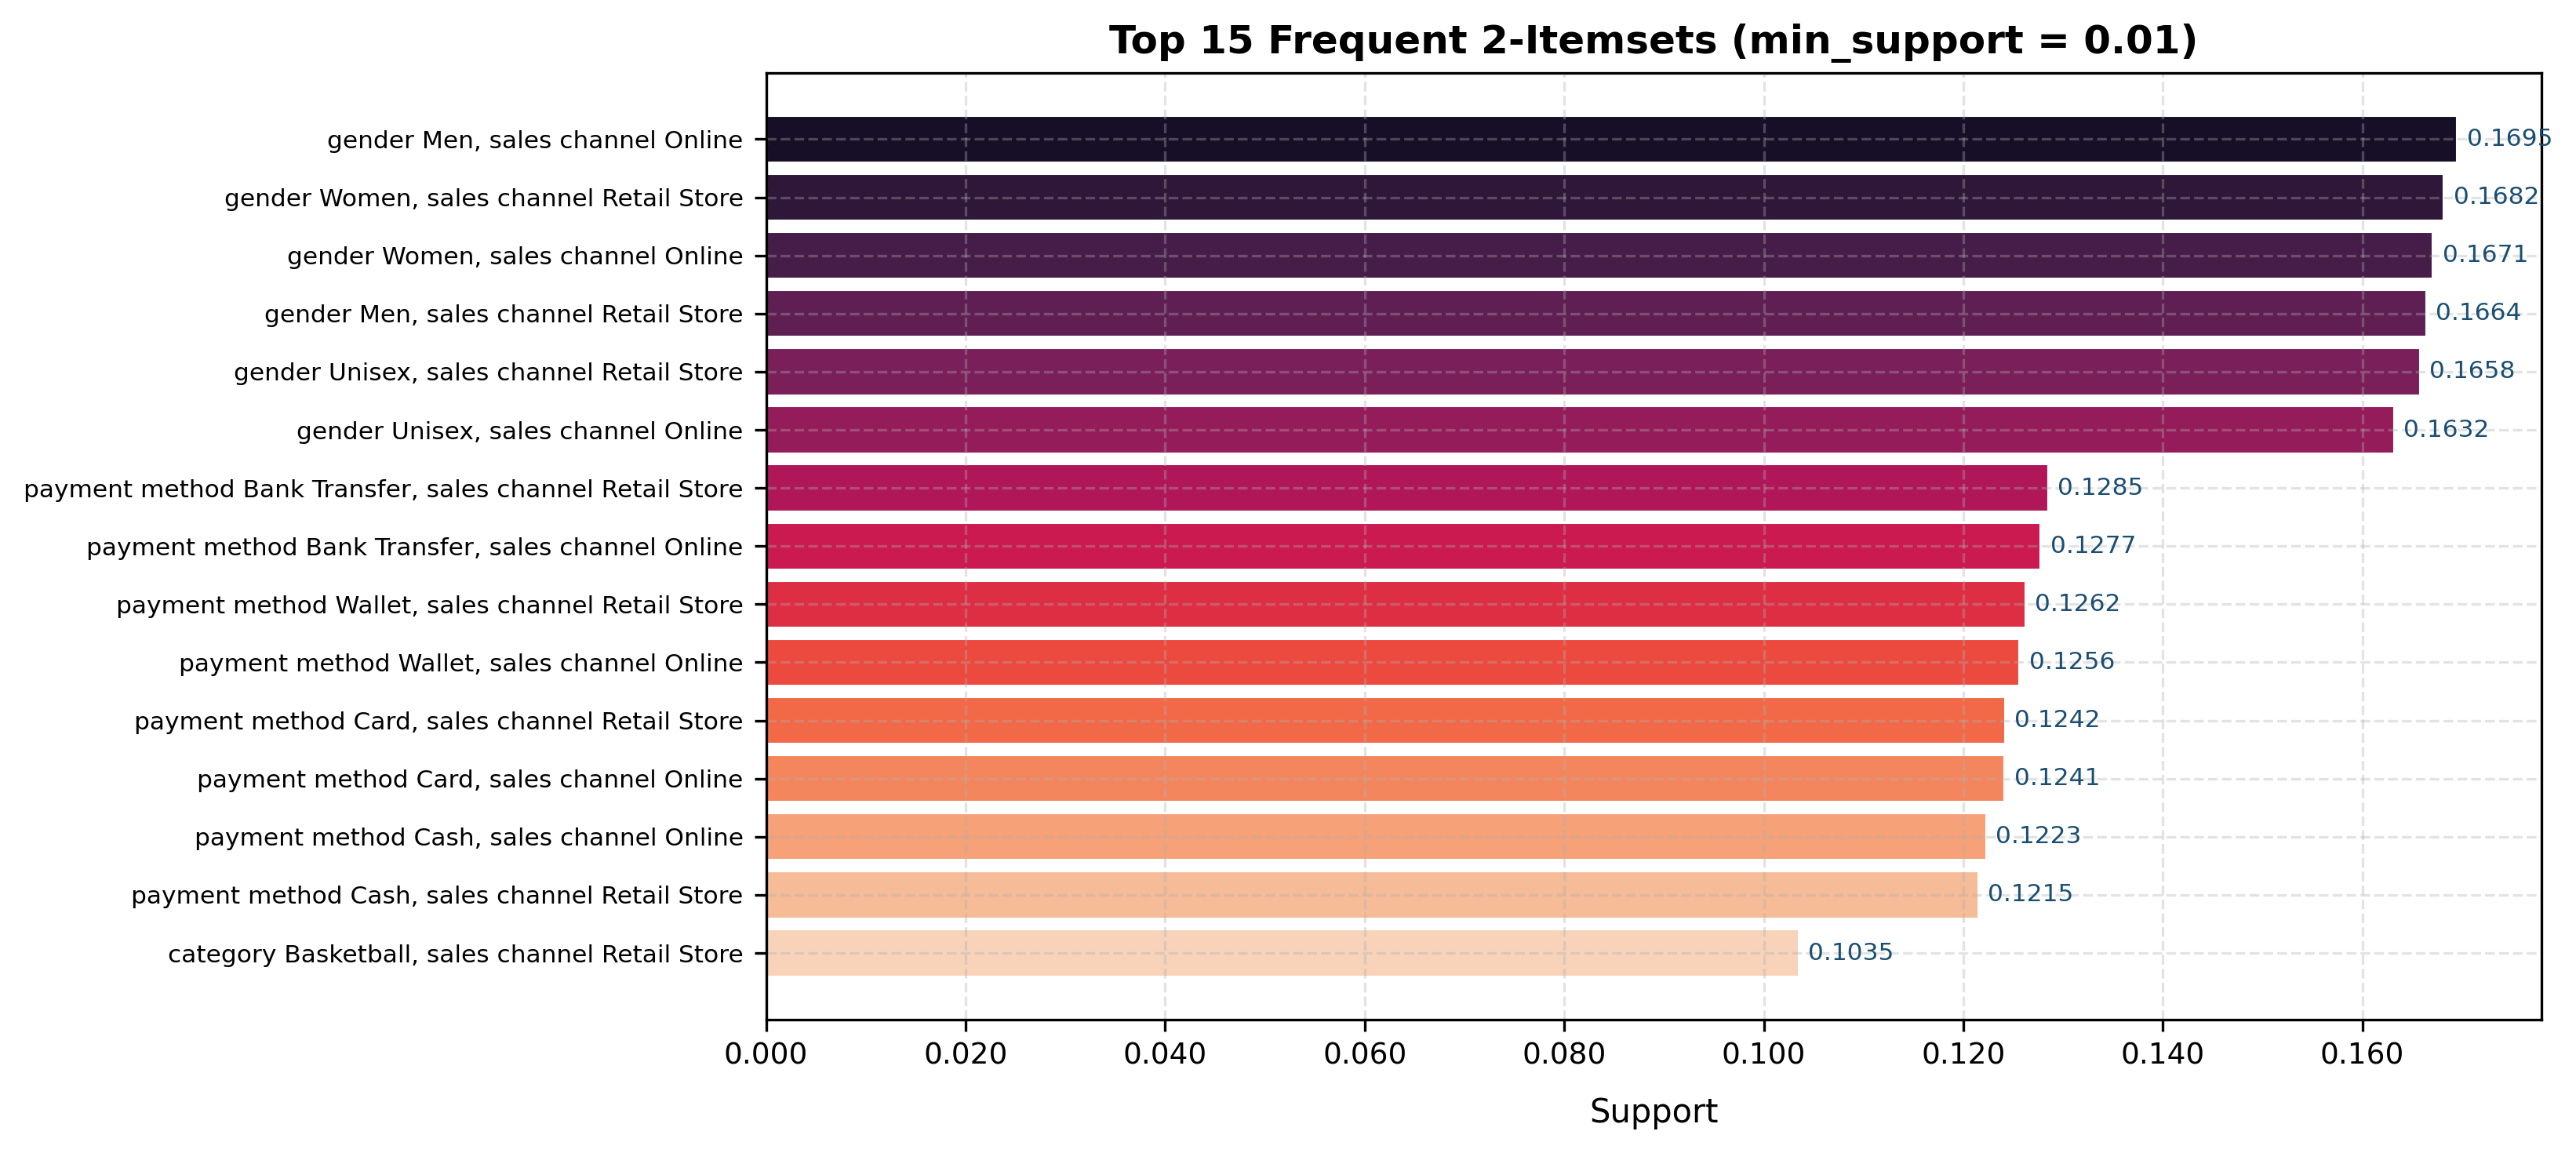

In [ ]:
# =============================================================
# MODELING ASSOCIATION: Apriori Algorithm
# =============================================================

# Apriori Parameter Configuration
MIN_SUPPORT    = 0.01
MIN_CONFIDENCE = 0.10
MIN_LIFT       = 1.0

# Frequent Itemsets Extraction
print('=' * 60)
print('  FREQUENT ITEMSETS EXTRACTION (APRIORI)')
print('=' * 60)
print(f'min_support    : {MIN_SUPPORT} ({MIN_SUPPORT*100:.0f}% of {len(ohe_df):,} transactions)')
print(f'min_confidence : {MIN_CONFIDENCE}')
print(f'min_lift       : {MIN_LIFT}')
print('\nProcessing... (please wait)\n')

frequent_itemsets = apriori(
    ohe_df,
    min_support      = MIN_SUPPORT,
    use_colnames     = True,
    max_len          = 2,
    verbose          = 1
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets_sorted    = frequent_itemsets.sort_values('support', ascending=False)

print(f'\n[✔] Total frequent itemsets found     : {len(frequent_itemsets)}')
print(f'    - 1-itemsets : {(frequent_itemsets["length"]==1).sum()}')
print(f'    - 2-itemsets : {(frequent_itemsets["length"]==2).sum()}')

print('\n-- Top 15 Frequent Itemsets by Support --')
display(frequent_itemsets_sorted.head(15)[['itemsets','support','length']]
        .reset_index(drop=True))
print()

# Visualisasi Top Frequent Itemsets
top_two = frequent_itemsets[frequent_itemsets['length']==2]\
          .sort_values('support', ascending=True).tail(15)
top_two_labels = [', '.join(sorted([i.replace('_',' ') for i in it]))
                  for it in top_two['itemsets']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    range(len(top_two)), top_two['support'],
    color=sns.color_palette("rocket_r", n_colors=len(top_two)),
    edgecolor='white', linewidth=0.5
)
ax.set_yticks(range(len(top_two)))
ax.set_yticklabels(top_two_labels, fontsize=7.5)
ax.set_xlabel('Support', labelpad=8)
ax.set_title('Top 15 Frequent 2-Itemsets (min_support = 0.01)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.3f}'))
for bar, val in zip(bars, top_two['support']):
    ax.annotate(f'{val:.4f}', (bar.get_width(), bar.get_y()+bar.get_height()/2),
                ha='left', va='center', fontsize=7.5, color='#1B4F72',
                xytext=(3,0), textcoords='offset points')
plt.tight_layout()
plt.savefig('gambar_4_14_frequent_itemsets.png', dpi=300, bbox_inches='tight')
plt.show()

---
### Evaluation — Association Rule Generation & Assessment
---


  ASSOCIATION RULE GENERATION RESULTS
Total rules generated (lift>1.0, conf>=10%)        : 270
Highest lift   : 1.0761
Average lift   : 1.0158

-- Top 10 Most Significant Association Rules (by Lift) --


,Antecedents,Consequents,Support,Confidence,Lift,Leverage
0,brand ASICS,country Germany,0.030467,0.178098,1.076122,0.002155
1,country Germany,brand ASICS,0.030467,0.184089,1.076122,0.002155
2,country UK,brand Nike,0.029767,0.176552,1.055512,0.001566
3,brand Nike,country UK,0.029767,0.177959,1.055512,0.001566
4,country UAE,brand Reebok,0.029933,0.175459,1.047309,0.001352
5,brand Reebok,country UAE,0.029933,0.178671,1.047309,0.001352
6,country USA,category Training,0.035200,0.210066,1.047187,0.001586
7,category Training,country USA,0.035200,0.175474,1.047187,0.001586
8,country India,brand Adidas,0.028467,0.171108,1.043766,0.001194
9,brand Adidas,country India,0.028467,0.173648,1.043766,0.001194


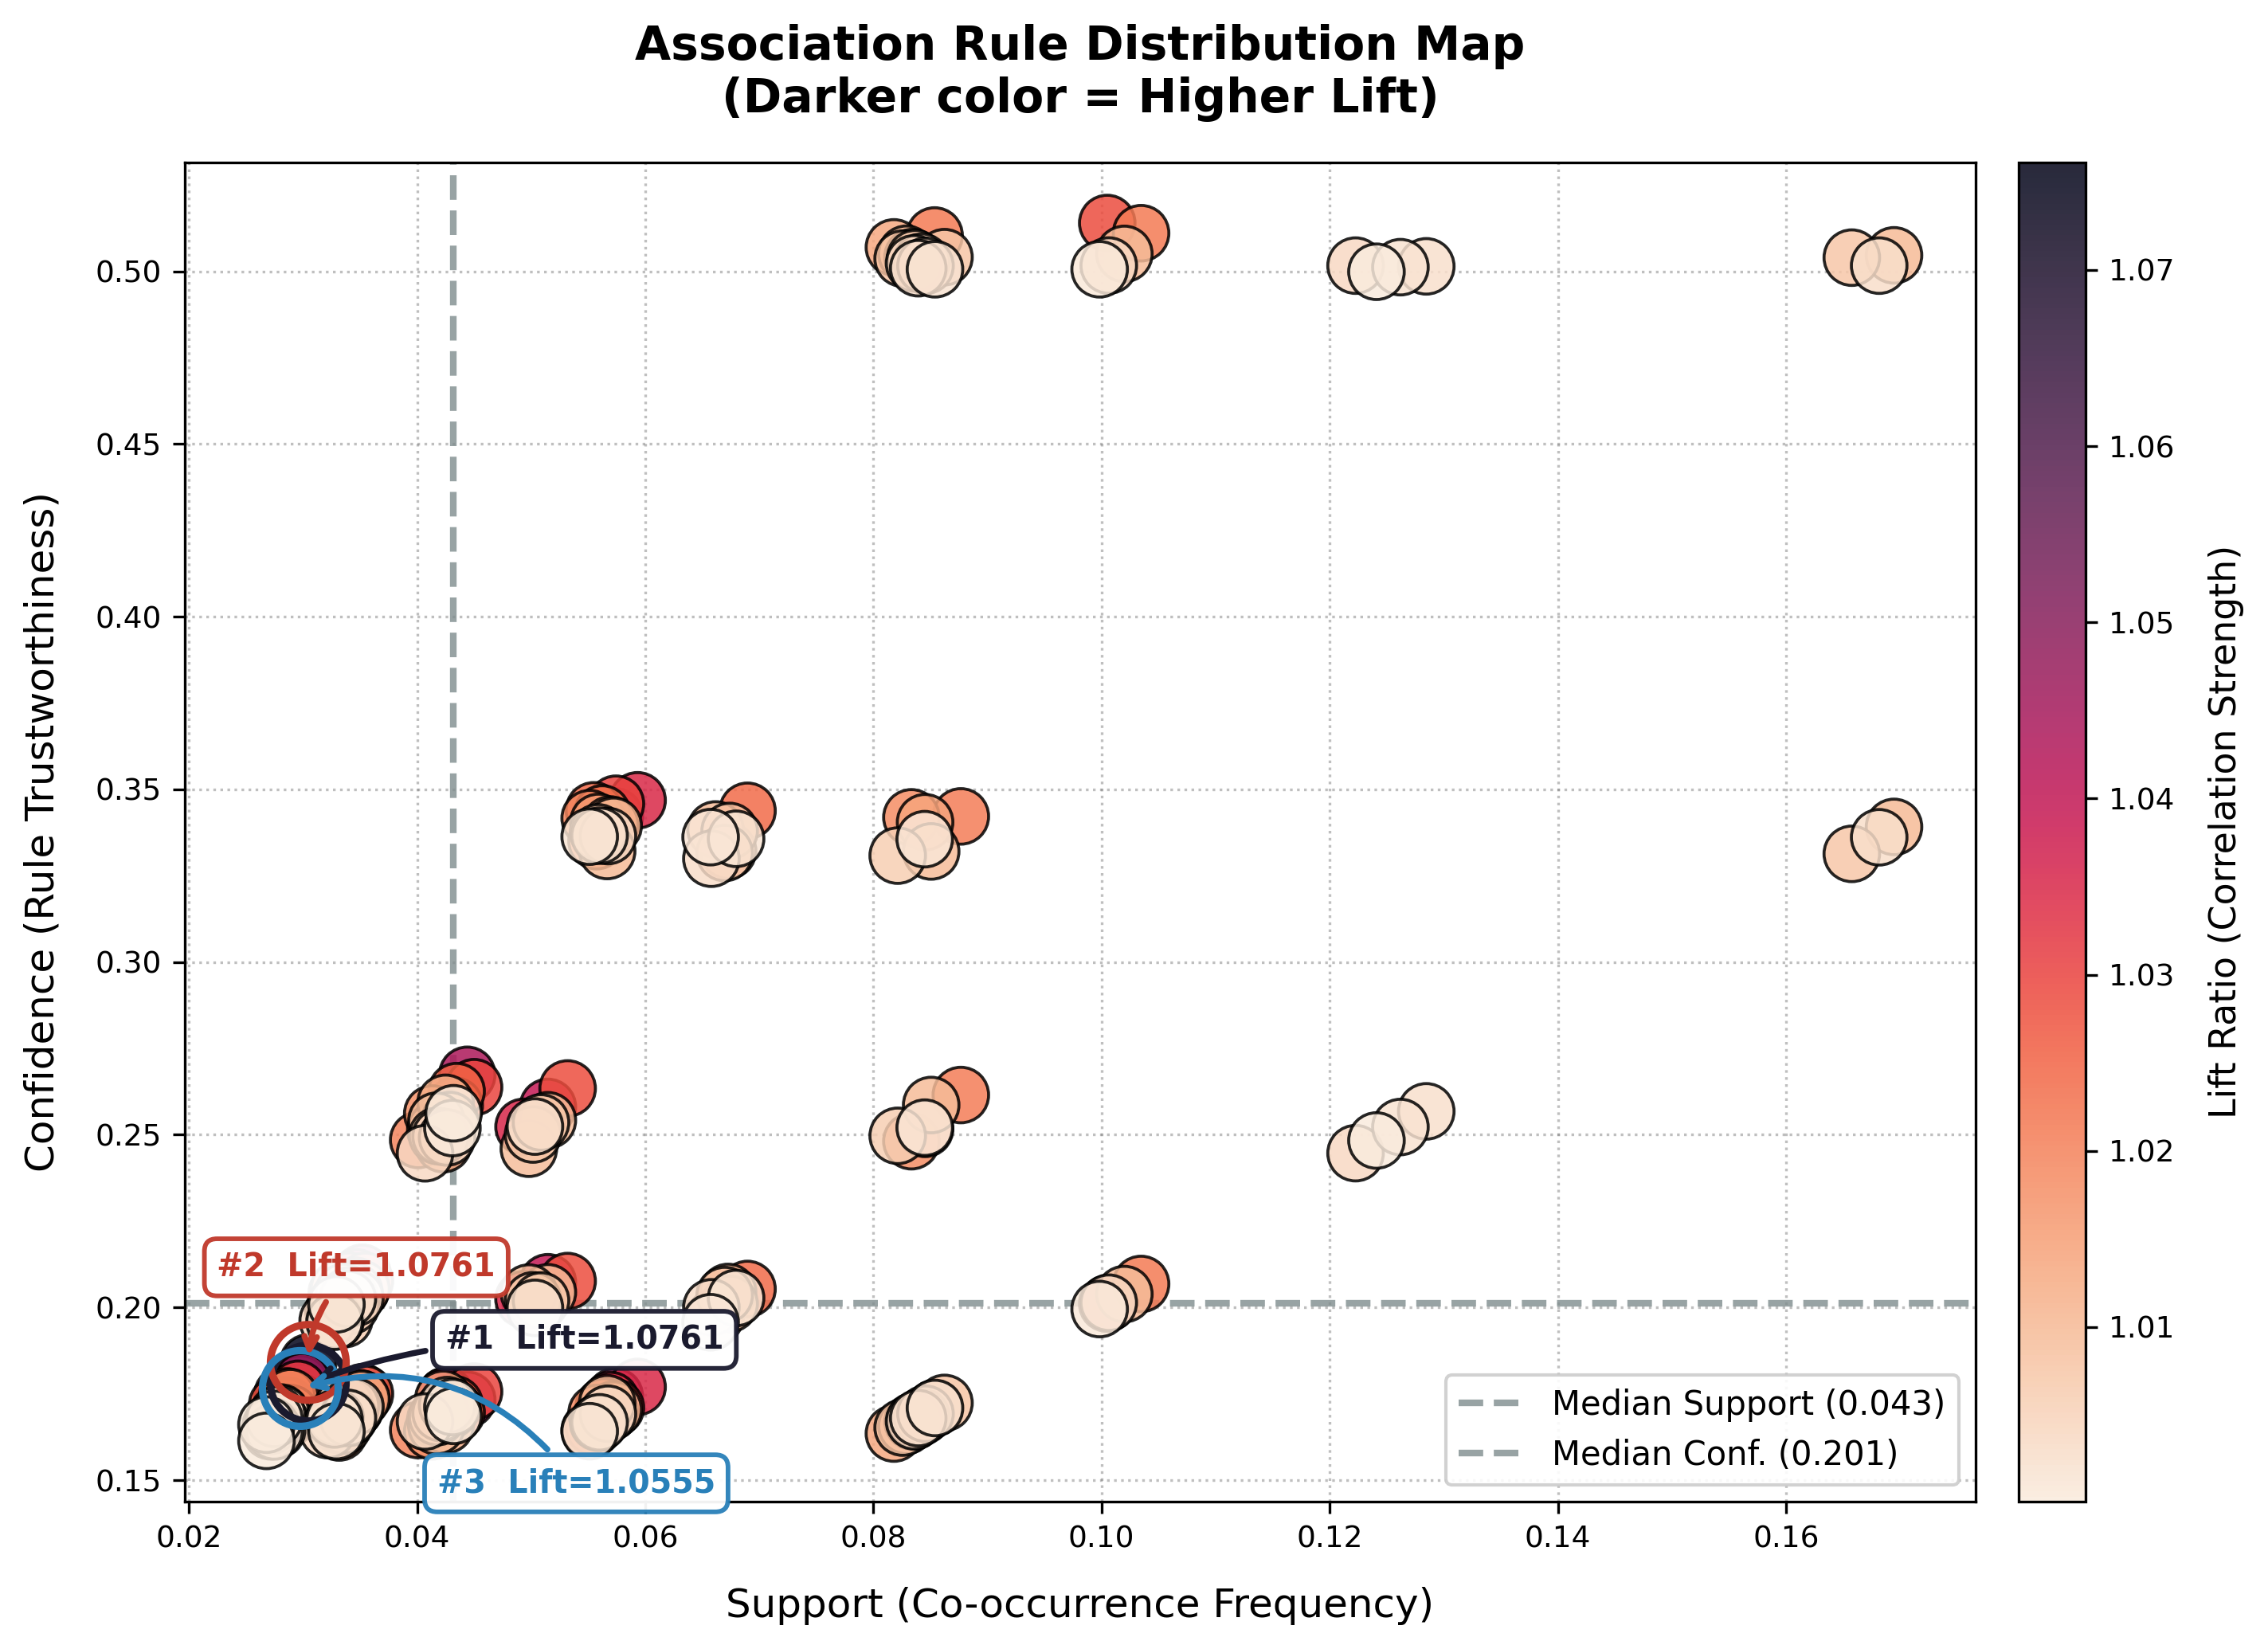

In [ ]:
# =============================================================
# EVALUATION: Association Rule Generation
# =============================================================

# Generate Association Rules from Frequent Itemsets
rules = association_rules(
    frequent_itemsets,
    metric           = 'lift',
    min_threshold    = MIN_LIFT,
    num_itemsets     = len(frequent_itemsets)
)
rules = rules[rules['confidence'] >= MIN_CONFIDENCE].copy()
rules['antecedents_str'] = rules['antecedents'].apply(
    lambda x: ', '.join(sorted([i.replace('_',' ') for i in x]))
)
rules['consequents_str'] = rules['consequents'].apply(
    lambda x: ', '.join(sorted([i.replace('_',' ') for i in x]))
)
rules_sorted = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print('=' * 60)
print('  ASSOCIATION RULE GENERATION RESULTS')
print('=' * 60)
print(f'Total rules generated (lift>1.0, conf>=10%)        : {len(rules_sorted)}')
print(f'Highest lift   : {rules_sorted["lift"].max():.4f}')
print(f'Average lift   : {rules_sorted["lift"].mean():.4f}')

print('\n-- Top 10 Most Significant Association Rules (by Lift) --')
top10 = rules_sorted[['antecedents_str','consequents_str',
                      'support','confidence','lift','leverage']].head(10)
top10.columns = ['Antecedents','Consequents','Support','Confidence','Lift','Leverage']
display(top10)
print()

cmap_scatter = sns.color_palette("rocket_r", as_cmap=True)

# GAMBAR 1: Scatter Plot (Support vs Confidence)
fig1, ax1 = plt.subplots(figsize=(10, 7))

sc = ax1.scatter(
    rules_sorted['support'],
    rules_sorted['confidence'],
    c=rules_sorted['lift'],
    cmap=cmap_scatter,
    s=280,
    alpha=0.85,
    edgecolors='black',
    linewidths=0.9,
    zorder=3
)

# Colorbar
cb = plt.colorbar(sc, ax=ax1, pad=0.02)
cb.set_label('Lift Ratio (Correlation Strength)', fontsize=11, labelpad=10)
cb.outline.set_linewidth(0.8)

# Labels & Title
ax1.set_xlabel('Support (Co-occurrence Frequency)', labelpad=10, fontsize=12)
ax1.set_ylabel('Confidence (Rule Trustworthiness)', labelpad=10, fontsize=12)
ax1.set_title('Association Rule Distribution Map\n(Darker color = Higher Lift)',
             fontweight='bold', fontsize=14, pad=15)

# Subtle grid in the background
ax1.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.5, zorder=0)

# Median Lines
xmid, ymid = rules_sorted['support'].median(), rules_sorted['confidence'].median()
ax1.axvline(xmid, color='#7f8c8d', lw=2, linestyle='--', alpha=0.8, label=f'Median Support ({xmid:.3f})')
ax1.axhline(ymid, color='#7f8c8d', lw=2, linestyle='--', alpha=0.8, label=f'Median Conf. ({ymid:.3f})')
ax1.legend(fontsize=10, frameon=True, facecolor='white', framealpha=0.9)

# Top 3 Lift Annotation — highlight ring + manual offset to prevent overlap
top3 = rules_sorted.nlargest(3, 'lift').reset_index(drop=True)

# Manual offsets to prevent overlap — adjust if still overlapping
OFFSETS = [
    (+0.012, +0.010),   # titik rank 1
    (-0.008, +0.025),   # titik rank 2
    (+0.012, -0.030),   # titik rank 3
]

RANK_COLORS = ['#1a1a2e', '#C0392B', '#2980B9']

for idx, (_, row) in enumerate(top3.iterrows()):
    dx, dy = OFFSETS[idx]
    color  = RANK_COLORS[idx]

    # Highlight ring — lingkaran ekstra di sekitar titik
    ax1.scatter(
        row['support'], row['confidence'],
        s=520, facecolors='none',
        edgecolors=color, linewidths=2.2, zorder=4
    )

    # Label + panah
    ax1.annotate(
        f"#{idx+1}  Lift={row['lift']:.4f}",
        xy=(row['support'], row['confidence']),
        xytext=(row['support'] + dx, row['confidence'] + dy),
        fontsize=9.5, fontweight='bold', color=color,
        arrowprops=dict(
            arrowstyle='->', color=color,
            lw=1.8, connectionstyle=f'arc3,rad={0.1 + idx*0.12}'
        ),
        bbox=dict(
            boxstyle='round,pad=0.4', facecolor='white',
            edgecolor=color, linewidth=1.4, alpha=0.95
        ),
        zorder=6
    )

plt.tight_layout()
plt.savefig('gambar_4_X_scatter_association.png', dpi=300, bbox_inches='tight')
plt.show()

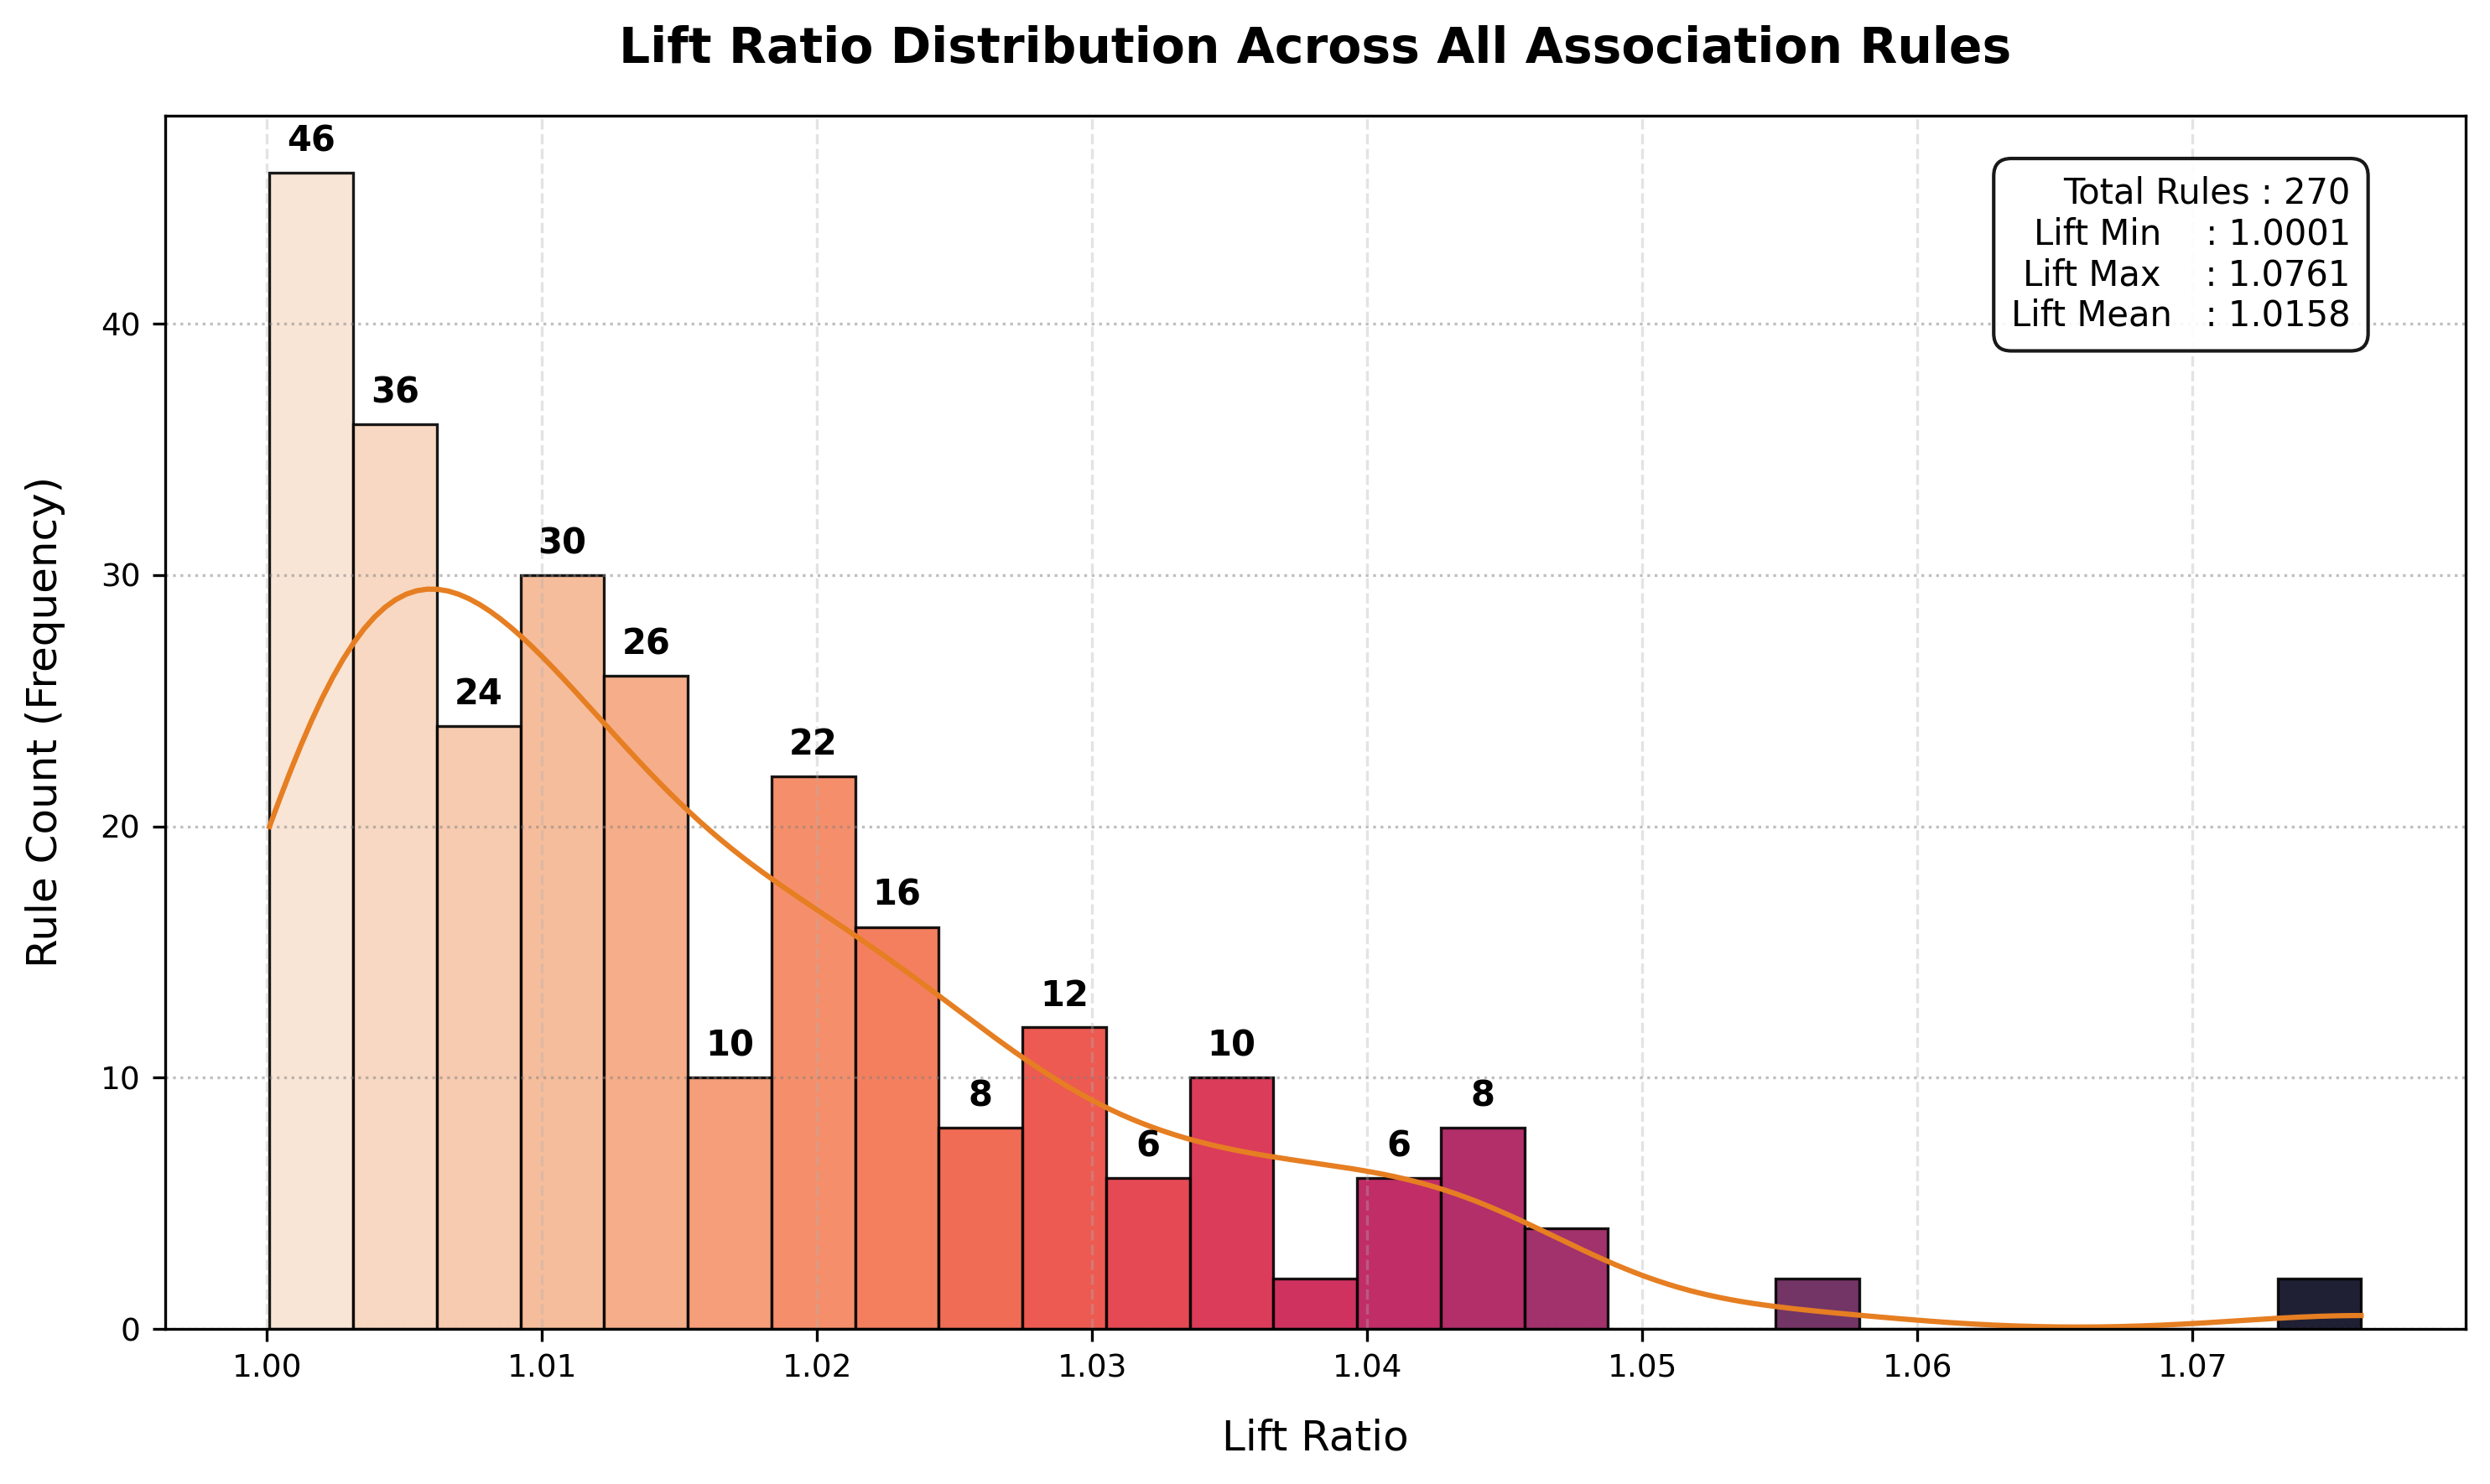


[✔] Association Evaluation Visualization complete.


In [ ]:
# --- FIGURE 2: Lift Distribution Histogram ---
fig2, ax2 = plt.subplots(figsize=(10, 6))
n_bins = 25

sns.histplot(
    data=rules_sorted, x='lift', bins=n_bins, kde=True,
    ax=ax2, color='#E67E22', edgecolor='black', linewidth=0.8, alpha=0.6, zorder=1
)

# Color histogram bars based on Lift (matching scatter colormap)
norm = plt.Normalize(rules_sorted['lift'].min(), rules_sorted['lift'].max())
for patch in ax2.patches:
    if patch.get_height() > 0:
        bin_center = patch.get_x() + patch.get_width() / 2
        patch.set_facecolor(cmap_scatter(norm(bin_center)))
        patch.set_alpha(0.9)
        patch.set_edgecolor('black')

ax2.set_xlabel('Lift Ratio', labelpad=10, fontsize=12)
ax2.set_ylabel('Rule Count (Frequency)', labelpad=10, fontsize=12)
ax2.set_title('Lift Ratio Distribution Across All Association Rules',
              fontweight='bold', fontsize=14, pad=15)

ax2.grid(True, axis='y', linestyle=':', linewidth=0.8, color='gray', alpha=0.5, zorder=0)

# Annotate bar values on top
threshold_anno = rules_sorted.shape[0] * 0.02
for p in ax2.patches:
    height = p.get_height()
    if height > threshold_anno:
        ax2.annotate(f'{int(height)}',
                     (p.get_x() + p.get_width() / 2, height),
                     ha='center', va='bottom', fontsize=10, fontweight='bold',
                     xytext=(0, 4), textcoords='offset points')

# Statistics box
stats_txt = (f"Total Rules : {len(rules_sorted):,}\n"
             f"Lift Min    : {rules_sorted['lift'].min():.4f}\n"
             f"Lift Max    : {rules_sorted['lift'].max():.4f}\n"
             f"Lift Mean   : {rules_sorted['lift'].mean():.4f}")
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black')
ax2.text(0.95, 0.95, stats_txt, transform=ax2.transAxes,
         fontsize=10, va='top', ha='right', bbox=props)

plt.tight_layout()
plt.savefig('gambar_4_X_hist_lift.png', dpi=300, bbox_inches='tight')
plt.show()
print('\n[✔] Association Evaluation Visualization complete.')

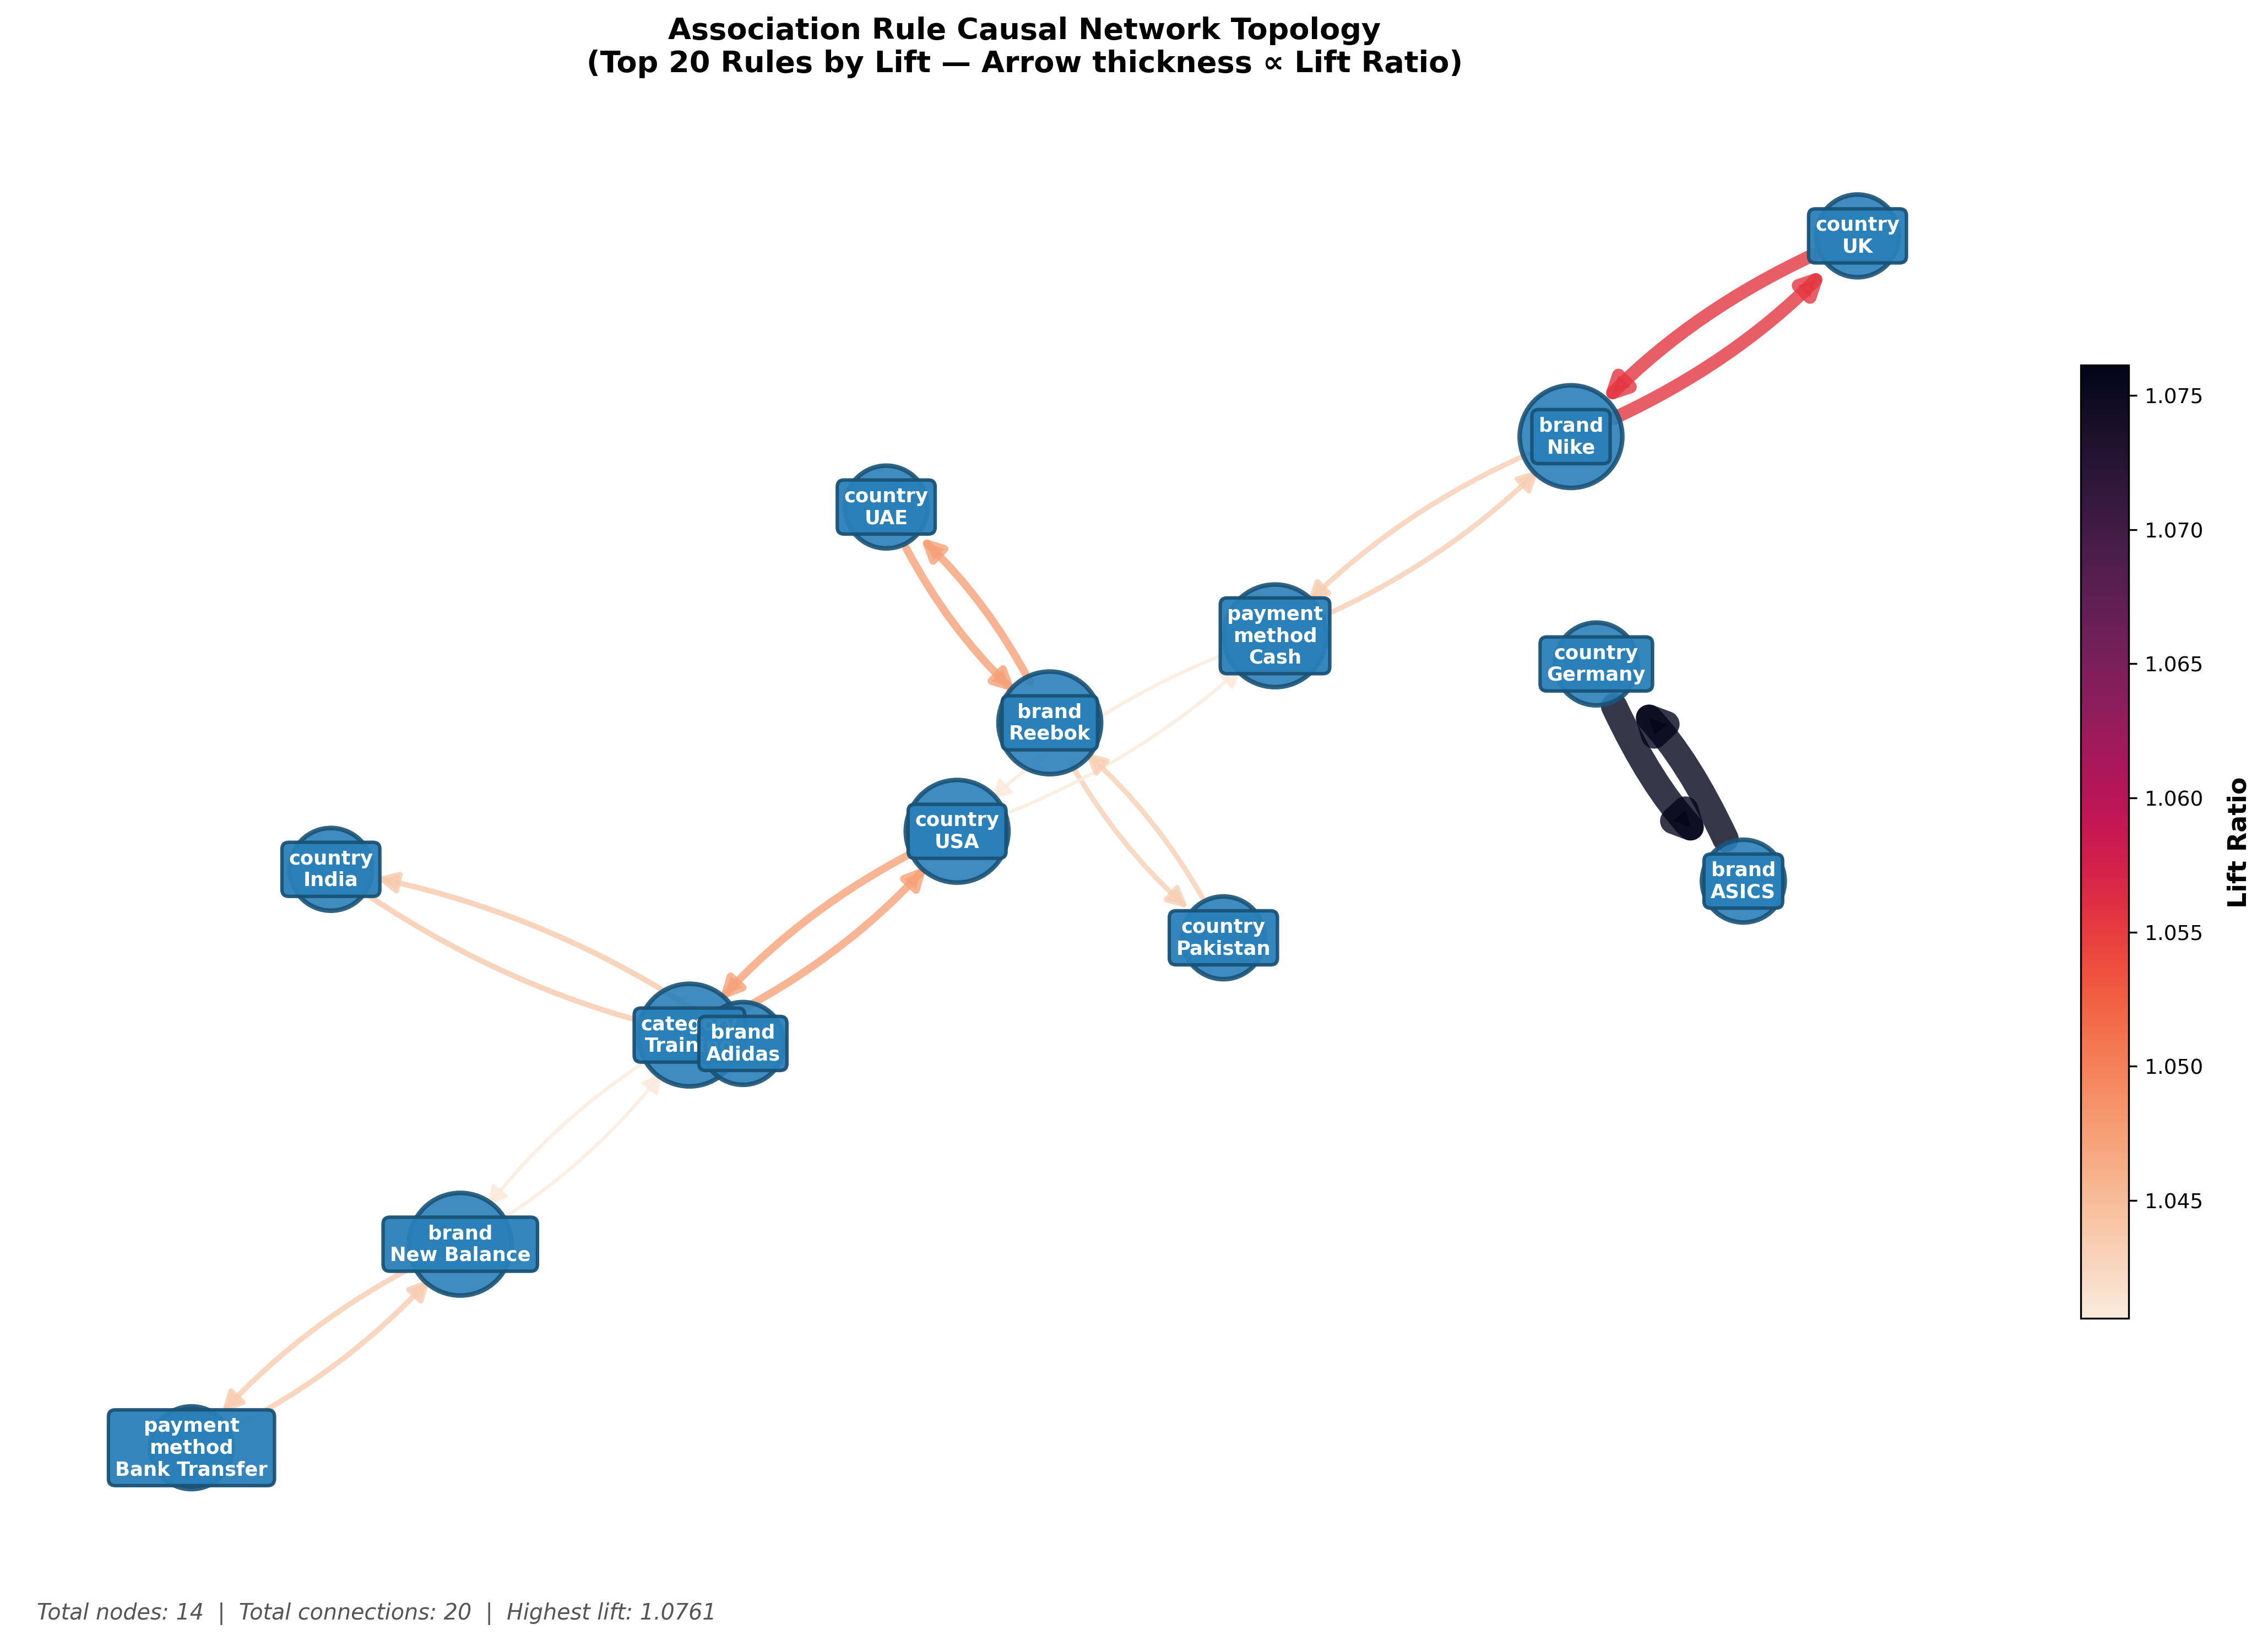


[✔] Hub with most connections: brand_Nike (degree=4)
[✔] Highest lift in graph: 1.0761


In [ ]:
# =====================================================================
# NETWORK GRAPH — ASSOCIATION RULE NETWORK TOPOLOGY
# =====================================================================

TOP_N = 20
rules_net = rules_sorted.head(TOP_N).copy()

G = nx.DiGraph()
for _, row in rules_net.iterrows():
    for a in list(row['antecedents']):
        for c in list(row['consequents']):
            # If edge already exists, keep the one with higher lift
            if G.has_edge(a, c):
                if row['lift'] > G[a][c]['lift']:
                    G[a][c] = {'lift': row['lift'], 'confidence': row['confidence']}
            else:
                G.add_edge(a, c, lift=row['lift'], confidence=row['confidence'])

pos = nx.kamada_kawai_layout(G, scale=2.5)

edge_lifts = [d['lift'] for _, _, d in G.edges(data=True)]
edge_widths = [(w - min(edge_lifts)) / (max(edge_lifts) - min(edge_lifts) + 1e-9) * 10 + 1.5
               for w in edge_lifts]
edge_colors = edge_lifts

node_degree = dict(G.degree())
node_sizes = [600 + node_degree[n] * 350 for n in G.nodes()]

fig, ax = plt.subplots(figsize=(15, 10))
ax.set_facecolor('#F8F9FA')
ax.set_title(f'Association Rule Causal Network Topology\n'
             f'(Top {TOP_N} Rules by Lift — Arrow thickness ∝ Lift Ratio)',
             fontsize=13, fontweight='bold', pad=16)

# Edges
edge_collection = nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=edge_colors, edge_cmap=sns.color_palette("rocket_r", as_cmap=True),
    width=edge_widths, alpha=0.80, arrows=True,
    arrowsize=18, arrowstyle='-|>',
    connectionstyle='arc3,rad=0.12',
    min_source_margin=20, min_target_margin=20
)

# Nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=node_sizes, node_color='#2980B9',
    edgecolors='#1A5276', linewidths=2.0, alpha=0.90
)

# Labels with background box for readability
for node, (x, y) in pos.items():
    label = node.replace('_', '\n') if '_' in node else node
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white',
            bbox=dict(facecolor='#2980B9', edgecolor='#1A5276',
                      boxstyle='round,pad=0.35', alpha=0.95, linewidth=1.5))

# Colorbar
sm = plt.cm.ScalarMappable(cmap=sns.color_palette("rocket_r", as_cmap=True),
    norm=plt.Normalize(vmin=min(edge_lifts), vmax=max(edge_lifts)))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.65, aspect=20)
cb.set_label('Lift Ratio', fontsize=11, fontweight='bold', labelpad=10)

# Legend info
info_text = (f'Total nodes: {len(G.nodes())}  |  '
             f'Total connections: {len(G.edges())}  |  '
             f'Highest lift: {max(edge_lifts):.4f}')
ax.text(0.01, -0.03, info_text, transform=ax.transAxes,
        fontsize=9.5, color='#555555', style='italic')

ax.axis('off')
plt.tight_layout()
plt.savefig('gambar_network_association.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n[✔] Hub with most connections: {max(node_degree, key=node_degree.get)} '
      f'(degree={max(node_degree.values())})')
print(f'[✔] Highest lift in graph: {max(edge_lifts):.4f}')

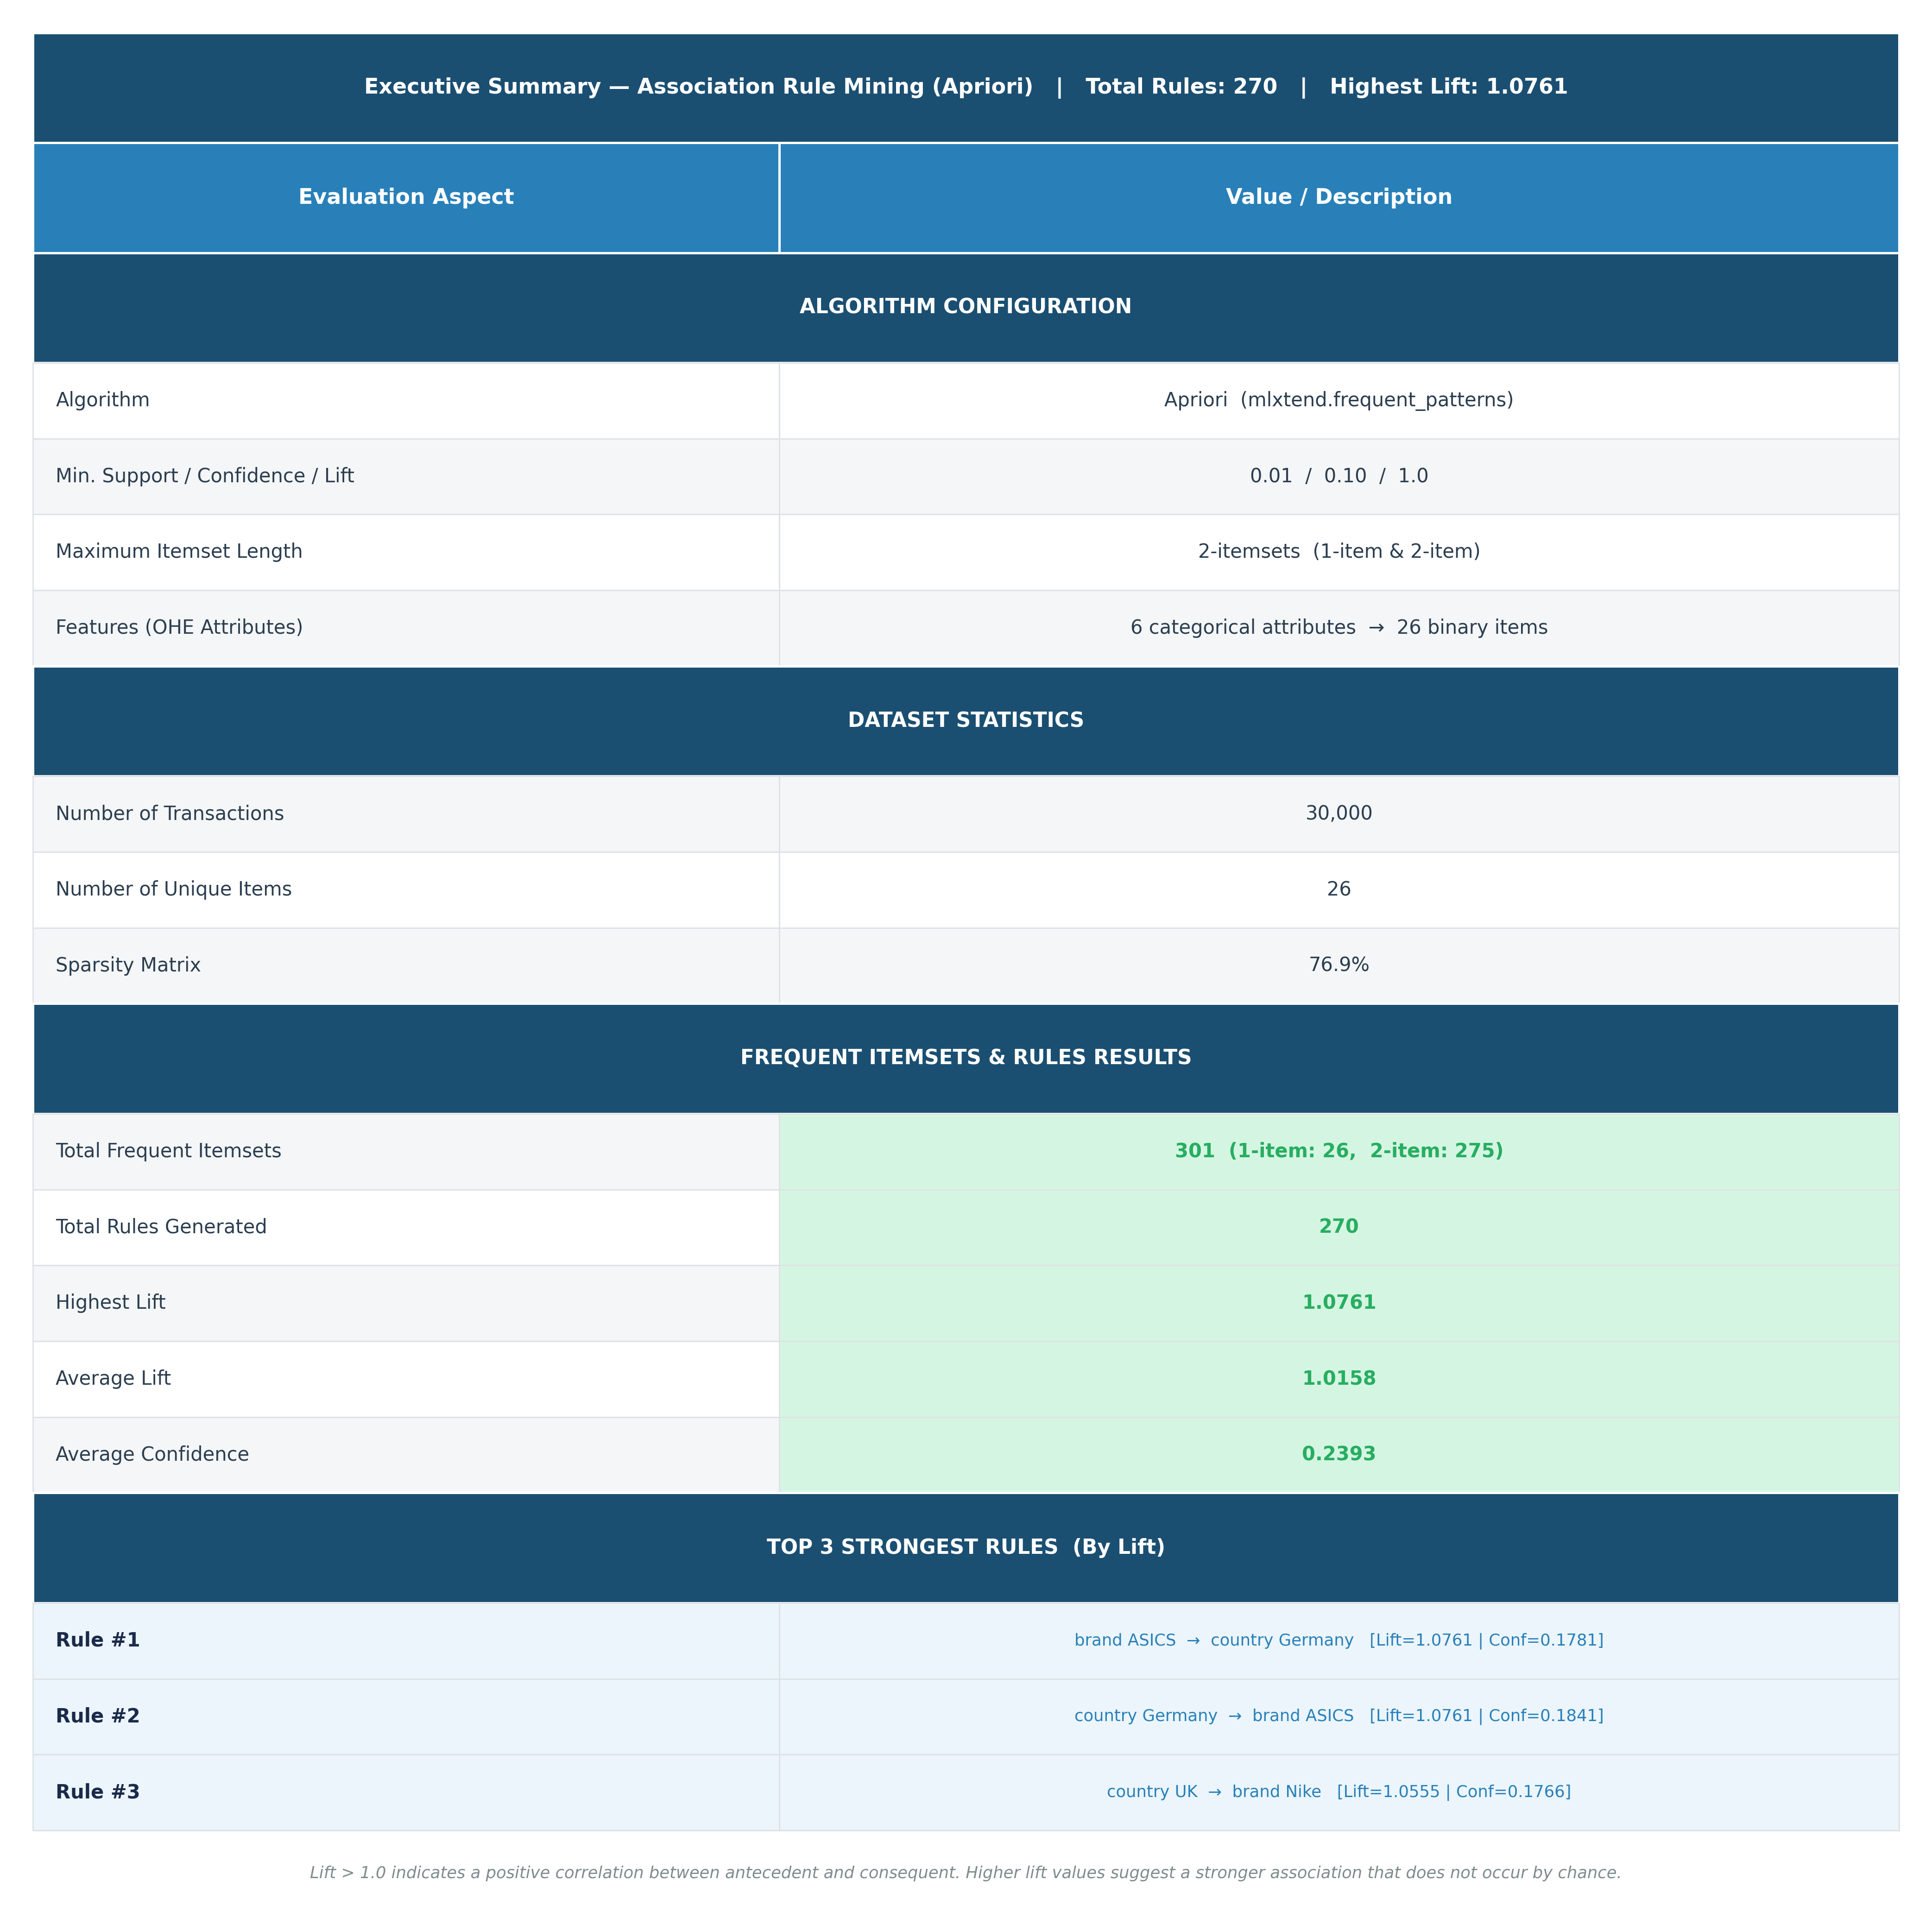

[✔] Association Executive Summary saved: assoc_ringkasan_eksekutif.png


In [ ]:
# =====================================================================
# EXECUTIVE SUMMARY — ASSOCIATION RULE MINING (APRIORI)
# =====================================================================

# ── Helper ──────────────────────────────────────────────────────────
def _fmt_rule_assoc(row, maxlen=65):
    ant = ', '.join(sorted([i.replace('_', ' ') for i in row['antecedents']]))
    con = ', '.join(sorted([i.replace('_', ' ') for i in row['consequents']]))
    s   = f'{ant}  →  {con}'
    return s if len(s) <= maxlen else s[:maxlen - 1] + '…'

_n1   = (frequent_itemsets['length'] == 1).sum()
_n2   = (frequent_itemsets['length'] == 2).sum()
_top1 = rules_sorted.iloc[0]
_top2 = rules_sorted.iloc[1]
_top3 = rules_sorted.iloc[2]

# ── Definisi baris tabel ─────────────────────────────────────────────
_ROWS_A = [
    ('section', 'ALGORITHM CONFIGURATION',                ''),
    ('info',    'Algorithm',                              'Apriori  (mlxtend.frequent_patterns)'),
    ('info',    'Min. Support / Confidence / Lift',
                f'{MIN_SUPPORT:.2f}  /  {MIN_CONFIDENCE:.2f}  /  {MIN_LIFT:.1f}'),
    ('info',    'Maximum Itemset Length',                 '2-itemsets  (1-item & 2-item)'),
    ('info',    'Features (OHE Attributes)',
                f'{len(basket_cols)} categorical attributes  →  {n_items} binary items'),
    ('section', 'DATASET STATISTICS',                     ''),
    ('info',    'Number of Transactions',                  f'{n_tx:,}'),
    ('info',    'Number of Unique Items',                  f'{n_items}'),
    ('info',    'Sparsity Matrix',                         f'{sparsity:.1f}%'),
    ('section', 'FREQUENT ITEMSETS & RULES RESULTS',       ''),
    ('metric',  'Total Frequent Itemsets',
                f'{len(frequent_itemsets)}  (1-item: {_n1},  2-item: {_n2})'),
    ('metric',  'Total Rules Generated',                   f'{len(rules_sorted):,}'),
    ('metric',  'Highest Lift',                            f'{rules_sorted["lift"].max():.4f}'),
    ('metric',  'Average Lift',                            f'{rules_sorted["lift"].mean():.4f}'),
    ('metric',  'Average Confidence',                      f'{rules_sorted["confidence"].mean():.4f}'),
    ('section', 'TOP 3 STRONGEST RULES  (By Lift)',         ''),
    ('rule',    'Rule #1',
                f'{_fmt_rule_assoc(_top1)}   [Lift={_top1["lift"]:.4f} | Conf={_top1["confidence"]:.4f}]'),
    ('rule',    'Rule #2',
                f'{_fmt_rule_assoc(_top2)}   [Lift={_top2["lift"]:.4f} | Conf={_top2["confidence"]:.4f}]'),
    ('rule',    'Rule #3',
                f'{_fmt_rule_assoc(_top3)}   [Lift={_top3["lift"]:.4f} | Conf={_top3["confidence"]:.4f}]'),
]

# ── Layout constants ─────────────────────────────────────────────────
_X0 = 0.01;  _WT = 0.98
_CW = [0.40, 0.60]          # Aspek | Nilai
_RH = 0.040;  _HH = 0.058   # row height: normal | section/header

_N_rows  = len(_ROWS_A)
_fig_h   = (_HH * 2 + _N_rows * _RH + 0.12) * 14

fig, ax = plt.subplots(figsize=(14, _fig_h))
fig.patch.set_facecolor('white')
ax.axis('off');  ax.set_xlim(0, 1);  ax.set_ylim(0, 1)

# ── Helper functions ─────────────────────────────────────────────────
def _cr_a(x, y, w, h, fc, ec='white', lw=1.2):
    ax.add_patch(plt.Rectangle(
        (x, y), w, h, facecolor=fc, edgecolor=ec,
        linewidth=lw, transform=ax.transAxes, clip_on=False))

def _ct_a(x, y, w, h, txt, fs=10, fc='#2C3E50', bold=False, align='center'):
    ax.text(
        x + w / 2 if align == 'center' else x + 0.012,
        y + h / 2, txt,
        transform=ax.transAxes, fontsize=fs,
        fontweight='bold' if bold else 'normal',
        color=fc, ha=align, va='center', clip_on=False)

# ── Palet warna ──────────────────────────────────────────────────────
_C_NAVY = '#1B4F72'
_C_BLUE   = '#2980B9'
_C_GREEN  = '#27AE60'
_C_BGGRN  = '#D5F5E3'
_C_BGBLUE = '#EBF5FB'

# ── Title Row ────────────────────────────────────────────────────────
_y = 0.99
_cr_a(_X0, _y - _HH, _WT, _HH, _C_NAVY)
_ct_a(_X0, _y - _HH, _WT, _HH,
      f'Executive Summary — Association Rule Mining (Apriori)'
      f'   |   Total Rules: {len(rules_sorted):,}'
      f'   |   Highest Lift: {rules_sorted["lift"].max():.4f}',
      fs=11, fc='white', bold=True)

# ── Column Header Row ─────────────────────────────────────────────────
_y -= _HH
_cr_a(_X0,                _y - _HH, _CW[0] * _WT, _HH, _C_BLUE)
_cr_a(_X0 + _CW[0] * _WT, _y - _HH, _CW[1] * _WT, _HH, _C_BLUE)
_ct_a(_X0,                _y - _HH, _CW[0] * _WT, _HH, 'Evaluation Aspect',    fs=11, fc='white', bold=True)
_ct_a(_X0 + _CW[0] * _WT, _y - _HH, _CW[1] * _WT, _HH, 'Value / Description', fs=11, fc='white', bold=True)
_y -= _HH

# ── Data Rows ─────────────────────────────────────────────────────────
for _ri, (_tp, _lbl, _val) in enumerate(_ROWS_A):
    _rh  = _HH if _tp == 'section' else _RH
    _y  -= _rh
    _bgz = '#F4F6F7' if _ri % 2 == 0 else 'white'

    if _tp == 'section':
        _cr_a(_X0, _y, _WT, _rh, _C_NAVY)
        _ct_a(_X0, _y, _WT, _rh, _lbl, fs=10.5, fc='white', bold=True)

    elif _tp == 'metric':
        _cr_a(_X0,                _y, _CW[0] * _WT, _rh, _bgz,     ec='#DEE2E6', lw=0.7)
        _cr_a(_X0 + _CW[0] * _WT, _y, _CW[1] * _WT, _rh, _C_BGGRN, ec='#DEE2E6', lw=0.7)
        _ct_a(_X0,                _y, _CW[0] * _WT, _rh, _lbl, fs=10, fc='#2C3E50', align='left')
        _ct_a(_X0 + _CW[0] * _WT, _y, _CW[1] * _WT, _rh, _val, fs=10, fc=_C_GREEN, bold=True)

    elif _tp == 'rule':
        _cr_a(_X0,                _y, _CW[0] * _WT, _rh, _C_BGBLUE, ec='#DEE2E6', lw=0.7)
        _cr_a(_X0 + _CW[0] * _WT, _y, _CW[1] * _WT, _rh, _C_BGBLUE, ec='#DEE2E6', lw=0.7)
        _ct_a(_X0,                _y, _CW[0] * _WT, _rh, _lbl, fs=10, fc='#1B2A4A', bold=True, align='left')
        _ct_a(_X0 + _CW[0] * _WT, _y, _CW[1] * _WT, _rh, _val, fs=8.5, fc='#2980B9')

    else:  # info
        _cr_a(_X0,                _y, _CW[0] * _WT, _rh, _bgz, ec='#DEE2E6', lw=0.7)
        _cr_a(_X0 + _CW[0] * _WT, _y, _CW[1] * _WT, _rh, _bgz, ec='#DEE2E6', lw=0.7)
        _ct_a(_X0,                _y, _CW[0] * _WT, _rh, _lbl, fs=10, fc='#2C3E50', align='left')
        _ct_a(_X0 + _CW[0] * _WT, _y, _CW[1] * _WT, _rh, _val, fs=10, fc='#2C3E50')

# ── Footnote ──────────────────────────────────────────────────────────
ax.text(0.5, _y - 0.025,
        'Lift > 1.0 indicates a positive correlation between antecedent and consequent. '
        'Higher lift values suggest a stronger association that does not occur by chance.',
        transform=ax.transAxes, fontsize=8.5, color='#7F8C8D',
        ha='center', style='italic', clip_on=False)

plt.tight_layout()
plt.savefig('assoc_ringkasan_eksekutif.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('[✔] Association Executive Summary saved: assoc_ringkasan_eksekutif.png')